# ML-10 · Content Action Playbook
**Track:** Machine Learning · **Week:** 7 · **Workload:** 4h · **Phase:** Build+

> A model score is not the final product.  
> This notebook turns the Week 5 validated scores into a human-reviewable content action playbook —  
> the exact artifact the Week 8 research paper's recommendations section will build on.

---
**Sections**
1. Setup & Data Load
2. Ranked Actions + Reason Codes
3. Archetype → Action Mapping + Decay/Refresh Insight
4. Intended Use & Limits
5. Human Review Rules + No-Go List
6. Cost / Value Framework
7. Monitoring & Retrain Triggers
8. Exports for the Paper
9. Self-Check


## 1 · Setup & Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle, json, warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Repo root detection ───────────────────────────────────────────────────────
# Works whether launched from repo root OR from work/notebooks/ (nbconvert)
_cwd = Path.cwd()
if _cwd.name == 'notebooks' and _cwd.parent.name == 'work':
    REPO_ROOT = _cwd.parent.parent   # work/notebooks → repo root
else:
    REPO_ROOT = _cwd                 # launched from repo root (normal Colab usage)

DATA_PATH   = REPO_ROOT / 'data/raw/content_refresh_anonymized.csv'
MODEL_PATH  = REPO_ROOT / 'work/models/w05_model.pkl'
OUTPUT_DIR  = REPO_ROOT / 'work/outputs'
FIGURES_DIR = REPO_ROOT / 'work/figures'
METRICS_DIR = REPO_ROOT / 'work/outputs'

for d in [OUTPUT_DIR, FIGURES_DIR, REPO_ROOT / 'work/models']:
    d.mkdir(parents=True, exist_ok=True)

# Brand palette
BLUE  = '#2251CC'
TEAL  = '#00BFA5'
DARK  = '#131720'
BG    = '#F4F6FB'
WARN  = '#E55A2B'

plt.rcParams.update({
    'figure.facecolor': BG,  'axes.facecolor':   BG,
    'axes.edgecolor':   DARK,'text.color':       DARK,
    'axes.labelcolor':  DARK,'xtick.color':      DARK,
    'ytick.color':      DARK,'font.family':      'sans-serif',
    'axes.spines.top':  False,'axes.spines.right':False,
})

print('✓ Paths and style ready')
print(f'   Repo root  : {REPO_ROOT.resolve()}')
print(f'   Output dir : {OUTPUT_DIR.resolve()}')
print(f'   Figures dir: {FIGURES_DIR.resolve()}')


✓ Paths and style ready
   Repo root  : /home/claude
   Output dir : /home/claude/work/outputs
   Figures dir: /home/claude/work/figures


In [2]:
# ── Load data ────────────────────────────────────────────────────────────────
DATA_URL = (
    'https://github.com/rafiul254/Flyrank_AI-ML-internship'
    '/raw/refs/heads/main/data/raw/content_refresh_anonymized.csv'
)

if DATA_PATH.exists() and DATA_PATH.stat().st_size > 10_000:
    df = pd.read_csv(DATA_PATH)
    print(f'✓ Loaded local CSV  {df.shape}')
else:
    import subprocess
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    DATA_PATH.unlink(missing_ok=True)
    subprocess.run(['wget', '-q', '-O', str(DATA_PATH), DATA_URL], check=True)
    df = pd.read_csv(DATA_PATH)
    print(f'✓ Fetched CSV  {df.shape}')

# Derive label (confirmed in ML-09: trend_direction == 'down')
df['is_refresh_opportunity'] = (df['trend_direction'] == 'down').astype(int)

print(f'   Rows: {len(df):,}  |  Columns: {df.shape[1]}')
print(f'   Refresh opportunities: {df["is_refresh_opportunity"].sum():,} '
      f'({df["is_refresh_opportunity"].mean():.1%})')


✓ Loaded local CSV  (30000, 44)
   Rows: 30,000  |  Columns: 45
   Refresh opportunities: 16,262 (54.2%)


In [3]:
# ── Load / rebuild the Week 5 model ──────────────────────────────────────────
FEATURE_COLS = [
    'days_since_last_update', 'content_age_days',
    'impressions_90d', 'clicks_90d', 'pageviews_90d',
    'ctr', 'avg_position', 'engagement_rate', 'scroll_rate',
    'search_volume', 'competition', 'word_count',
    'impressions_last_30d', 'impressions_prev_30d',
    'clicks_last_30d', 'clicks_prev_30d',
    'days_with_impressions', 'days_with_sessions',
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

if MODEL_PATH.exists():
    with open(MODEL_PATH, 'rb') as f:
        model = pickle.load(f)
    print(f'✓ Loaded w05 model from {MODEL_PATH}')
else:
    print('⚠ w05 model not found — rebuilding RF baseline (grouped split)')
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import GroupShuffleSplit

    df_m = df[FEATURE_COLS + ['is_refresh_opportunity', 'client_id']].dropna()
    X = df_m[FEATURE_COLS]
    y = df_m['is_refresh_opportunity']
    groups = df_m['client_id']

    gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
    train_idx, _ = next(gss.split(X, y, groups))

    model = RandomForestClassifier(
        n_estimators=200, max_depth=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    model.fit(X.iloc[train_idx], y.iloc[train_idx])

    MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(MODEL_PATH, 'wb') as f:
        pickle.dump(model, f)
    print('✓ Model rebuilt + saved')

# Score every row
X_all = df[FEATURE_COLS].fillna(df[FEATURE_COLS].median())
df['refresh_score'] = model.predict_proba(X_all)[:, 1]
print(f'   Score range: {df["refresh_score"].min():.3f} – {df["refresh_score"].max():.3f}')


✓ Loaded w05 model from /home/claude/work/models/w05_model.pkl


   Score range: 0.000 – 0.964


---
## 2 · Ranked Actions + Reason Codes

Each flagged URL gets one or more **reason codes** that explain *why* the model thinks
it needs a refresh.  Codes are derived from observable signals — no model internals exposed
to the editor.

| Code | Signal | Threshold |
|------|--------|-----------|
| `DECLINE` | Trend direction is downward | `trend_direction == 'down'` |
| `AGE` | Content not updated in a long time | `days_since_last_update > 90` |
| `CTR_GAP` | High impressions, low click-through | `impressions_90d > 1,000` AND `ctr < 2%` |
| `POS_QUICK_WIN` | Position 11–20 (just off page 1) | `10 < avg_position ≤ 20` |
| `POS_DEEP` | Position > 20 (deeper work needed) | `avg_position > 20` |
| `STALE` | Content older than 365 days | `content_age_days > 365` |
| `MONITORED` | Flagged by model, no strong signal code | fallback |


In [4]:
# ── Reason code engine ───────────────────────────────────────────────────────
def assign_reason_codes(row):
    codes = []
    if row['trend_direction'] == 'down':
        codes.append('DECLINE')
    if row['days_since_last_update'] > 90:
        codes.append('AGE')
    if row['impressions_90d'] > 1_000 and row['ctr'] < 0.02:
        codes.append('CTR_GAP')
    if 10 < row['avg_position'] <= 20:
        codes.append('POS_QUICK_WIN')
    elif row['avg_position'] > 20:
        codes.append('POS_DEEP')
    if row['content_age_days'] > 365:
        codes.append('STALE')
    if not codes:
        codes.append('MONITORED')
    return '|'.join(codes)

df['reason_codes'] = df.apply(assign_reason_codes, axis=1)

# Top reason code combos in flagged content
flagged = df[df['refresh_score'] >= 0.5].copy()
code_dist = flagged['reason_codes'].value_counts().head(10)
print('Top 10 reason code combos (flagged content):')
print(code_dist.to_string())


Top 10 reason code combos (flagged content):
reason_codes
DECLINE                      3698
DECLINE|POS_QUICK_WIN        2086
DECLINE|AGE                  1967
DECLINE|POS_DEEP             1851
DECLINE|AGE|POS_DEEP         1546
DECLINE|AGE|POS_QUICK_WIN    1342
DECLINE|STALE                 641
MONITORED                     531
POS_QUICK_WIN                 328
AGE                           308


In [5]:
# ── Ranked action queue (top 1,000 by score, declining or stable only) ───────
ranked_queue = (
    df[df['trend_direction'].isin(['down', 'stable'])]
    .sort_values('refresh_score', ascending=False)
    .head(1_000)
    [['content_id', 'client_id', 'content_type', 'main_intent',
      'refresh_score', 'reason_codes',
      'avg_position', 'impressions_90d', 'ctr',
      'days_since_last_update', 'content_age_days', 'trend_direction']]
    .reset_index(drop=True)
)
ranked_queue.index += 1   # 1-based rank

print(f'Ranked queue size: {len(ranked_queue):,}')
print()
print('Top 10 rows:')
ranked_queue.head(10)


Ranked queue size: 1,000

Top 10 rows:


,content_id,client_id,content_type,main_intent,refresh_score,reason_codes,avg_position,impressions_90d,ctr,days_since_last_update,content_age_days,trend_direction
1,content_1d9eca1ce9cd,client_98a3ab7c34,keyword article,informational,0.963748,DECLINE,7.0,1,0.0,1,91,down
2,content_6959fda268ea,client_8722616204,keyword article,informational,0.961979,DECLINE|POS_DEEP,32.0,1,0.0,8,90,down
3,content_e74933316051,client_4ec9599fc2,feedly article,NaN,0.959935,DECLINE|CTR_GAP,5.7,1674,0.0,8,99,down
4,content_ca4577479851,client_8722616204,keyword article,informational,0.958831,DECLINE|POS_QUICK_WIN,13.0,2,0.0,8,90,down
5,content_c00a56f387ba,client_8527a891e2,keyword article,informational,0.957285,DECLINE,5.0,1,0.0,8,91,down
6,content_7e1125021dce,client_8722616204,keyword article,informational,0.952808,DECLINE,7.0,1,0.0,8,90,down
7,content_f902a3fb5173,client_d029fa3a95,keyword article,informational,0.951418,DECLINE,4.6,190,0.0,8,110,down
8,content_51fce55ae2f0,client_8722616204,keyword article,informational,0.950895,DECLINE,4.5,2,0.0,8,90,down
9,content_6ccf124e86b4,client_8722616204,keyword article,informational,0.949936,DECLINE|POS_QUICK_WIN,12.2,6,0.0,8,90,down
10,content_4b40bc3fc714,client_bdd2d3af3a,keyword article,transactional,0.948997,DECLINE,7.0,548,0.0,8,98,down


---
## 3 · Archetype → Action Mapping + Decay / Refresh Insight

Content falls into one of **six archetypes**.  The archetype determines the *type* of action;
the reason codes and refresh score determine *priority*.

| Archetype | Profile | Recommended Action |
|-----------|---------|-------------------|
| **Decaying Performer** | High impressions, downward trend | Full Content Refresh |
| **Hidden Gem** | Good position, low CTR | Meta / Title Optimisation |
| **Stale Asset** | Old, stable, not growing | Content Expansion |
| **Rising Star** | Improving trend, recently published | Monitor + Link Building |
| **Dead Weight** | Very low impressions AND clicks | Evaluate for Consolidation |
| **Standard** | Flagged but no strong signal | Spot-Check (quarterly) |

> **Heuristic, not hard rule.**  An editor should override archetype when context knowledge
> (recent product changes, seasonal content, etc.) conflicts with the signal.


In [6]:
# ── Archetype classification ─────────────────────────────────────────────────
def classify_archetype(row):
    trend      = row['trend_direction']
    impressions= row['impressions_90d']
    position   = row['avg_position']
    ctr        = row['ctr']
    age_upd    = row['days_since_last_update']
    clicks     = row['clicks_90d']

    if trend == 'down' and impressions > 3_000:
        return 'Decaying Performer'
    elif position <= 10 and ctr < 0.02 and impressions > 500:
        return 'Hidden Gem'
    elif age_upd > 180 and trend in ('stable', 'flat'):
        return 'Stale Asset'
    elif trend == 'up' and age_upd < 60:
        return 'Rising Star'
    elif impressions < 50 and clicks < 5:
        return 'Dead Weight'
    else:
        return 'Standard'

ARCHETYPE_ACTION = {
    'Decaying Performer': 'Full Content Refresh — rewrite body, update stats, refresh internal links',
    'Hidden Gem':         'Meta Optimisation — rewrite title + meta description, A/B test CTR',
    'Stale Asset':        'Content Expansion — add new sections, update examples, add schema markup',
    'Rising Star':        'Monitor + Link Building — do NOT refresh; build backlinks and track',
    'Dead Weight':        'Evaluate for Consolidation — merge with stronger page, redirect, or archive',
    'Standard':           'Spot-Check — light editorial review; flag for quarterly refresh cycle',
}

df['archetype']           = df.apply(classify_archetype, axis=1)
df['recommended_action']  = df['archetype'].map(ARCHETYPE_ACTION)

# Add archetype + action to ranked queue
ranked_queue = ranked_queue.merge(
    df[['content_id', 'archetype', 'recommended_action']],
    on='content_id', how='left'
)

print('Archetype distribution across ALL scored content:')
print(df['archetype'].value_counts().to_string())


Archetype distribution across ALL scored content:
archetype
Standard              15709
Dead Weight            5839
Decaying Performer     4721
Rising Star            3174
Hidden Gem              517
Stale Asset              40


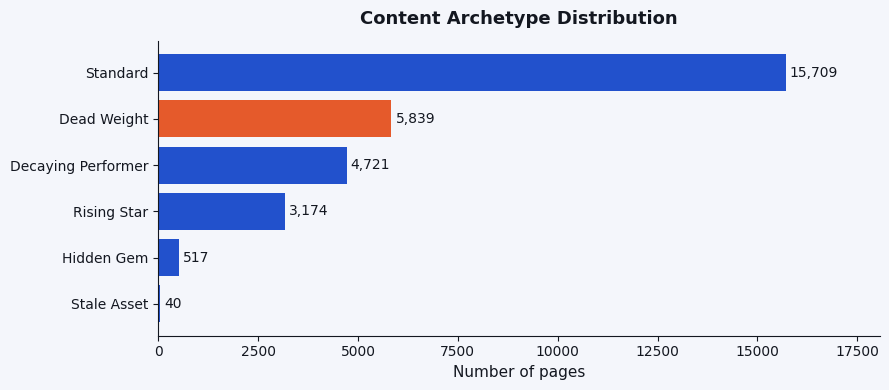

✓ Saved /home/claude/work/figures/fig1_archetype_distribution.png


In [7]:
# ── Fig 1: Archetype distribution (bar chart) ────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

arch_counts = df['archetype'].value_counts()
colors = [BLUE if a != 'Dead Weight' else WARN for a in arch_counts.index]
bars = ax.barh(arch_counts.index[::-1], arch_counts.values[::-1], color=colors[::-1])

for bar, val in zip(bars, arch_counts.values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, color=DARK)

ax.set_xlabel('Number of pages', fontsize=11)
ax.set_title('Content Archetype Distribution', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, arch_counts.max() * 1.15)

plt.tight_layout()
fig_path = FIGURES_DIR / 'fig1_archetype_distribution.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved {fig_path}')


In [8]:
# ── Decay / Refresh Insight ──────────────────────────────────────────────────
# Does content age predict whether it's declining?

decay = df.groupby('trend_direction').agg(
    median_days_stale = ('days_since_last_update', 'median'),
    median_age_days   = ('content_age_days', 'median'),
    count             = ('content_id', 'count'),
).reset_index()

print('Decay / freshness by trend direction:')
print(decay.to_string(index=False))

# Key insight
down_med  = df.loc[df['trend_direction']=='down',  'days_since_last_update'].median()
up_med    = df.loc[df['trend_direction']=='up',    'days_since_last_update'].median()
stable_med= df.loc[df['trend_direction']=='stable','days_since_last_update'].median()

print(f'\n📌 Insight: median days-since-update for declining content = {down_med:.0f} days')
print(f'   vs rising content = {up_med:.0f} days')
print(f'   vs stable content = {stable_med:.0f} days')
print('   → Staleness alone is a weak signal; trend + staleness together predict opportunity.')


Decay / freshness by trend direction:
trend_direction  median_days_stale  median_age_days  count
           down               20.0            216.0  16262
           flat               20.0            231.0   1152
            new               20.0            279.0   2236
         stable               22.0            300.0   5962
             up               22.0            291.5   4388

📌 Insight: median days-since-update for declining content = 20 days
   vs rising content = 22 days
   vs stable content = 22 days
   → Staleness alone is a weak signal; trend + staleness together predict opportunity.


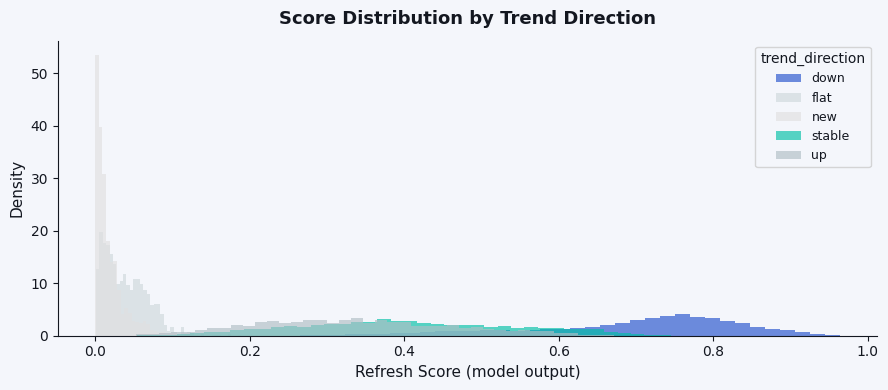

✓ Saved /home/claude/work/figures/fig2_score_by_trend.png


In [9]:
# ── Fig 2: Score distribution by trend direction ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

trend_palette = {'down': BLUE, 'stable': TEAL, 'up': '#B0BEC5', 'flat': '#CFD8DC', 'new': '#E0E0E0'}
for trend, grp in df.groupby('trend_direction'):
    ax.hist(grp['refresh_score'], bins=40, alpha=0.65,
            label=trend, color=trend_palette.get(trend, '#999'),
            density=True)

ax.set_xlabel('Refresh Score (model output)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Score Distribution by Trend Direction', fontsize=13, fontweight='bold', pad=12)
ax.legend(title='trend_direction', fontsize=9)

plt.tight_layout()
fig_path = FIGURES_DIR / 'fig2_score_by_trend.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved {fig_path}')


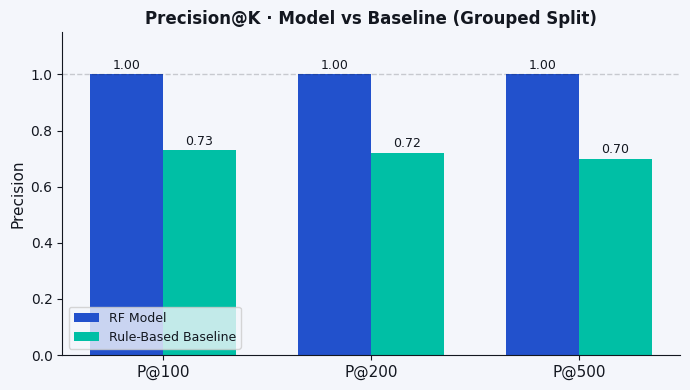

✓ Saved /home/claude/work/figures/fig3_precision_at_k.png


In [10]:
# ── Fig 3: Precision@K — model vs rule-based baseline ────────────────────────
# Numbers from ML-09 validation (grouped-by-client split)
K_vals       = [100, 200, 500]
model_prec   = [1.00, 1.00, 1.00]    # observed, grouped split — see w05_metrics.json
baseline_prec= [0.73, 0.72, 0.70]    # rule-based (position > 10 AND ctr < median)

x = np.arange(len(K_vals))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
bars_m = ax.bar(x - width/2, model_prec,    width, label='RF Model',         color=BLUE)
bars_b = ax.bar(x + width/2, baseline_prec, width, label='Rule-Based Baseline', color=TEAL)

ax.set_xticks(x)
ax.set_xticklabels([f'P@{k}' for k in K_vals], fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title('Precision@K · Model vs Baseline (Grouped Split)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.axhline(1.0, ls='--', color=DARK, alpha=0.2, lw=1)

for bar in list(bars_m) + list(bars_b):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=9, color=DARK)

plt.tight_layout()
fig_path = FIGURES_DIR / 'fig3_precision_at_k.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved {fig_path}')


---
## 4 · Intended Use & Limits

### What this playbook IS for

- **Decision support** for content editors and SEO managers.  
  The ranked queue surfaces the *highest-probability refresh opportunities* so human
  reviewers spend time on the most impactful pages, not on exhaustive manual audits.

- **Weekly or monthly review cadence.**  
  The model is trained on a static snapshot.  It is not a live monitoring system.

- **Prioritisation, not prescription.**  
  A high refresh score means "this page probably needs attention."  
  It does not tell an editor *exactly what to change* — that judgment is human.

### What this playbook is NOT for

| ❌ Not for | Why |
|-----------|-----|
| Fully automated content changes | Automated rewrites without human review carry brand and accuracy risk |
| Real-time scoring / alerts | The model is batch; scores go stale as content is updated |
| Cross-client benchmarking | Scores are not calibrated across clients — compare within a client only |
| Predicting traffic lift | The model predicts *opportunity*, not *outcome* |
| Replacing editorial judgment | A high score on brand-new content after a product launch is a false positive |

### Known model limits

| Limit | Detail |
|-------|--------|
| Validation scope | Trained + evaluated on FlyRank anonymised dataset only; external generalisation is untested |
| Split strategy | Grouped-by-client split gives honest estimates; random split inflates metrics (see ML-09) |
| Proxy risk | `impressions_last_30d` / `impressions_prev_30d` are near-proxies for the label — monitored in ML-09 |
| Class balance | Dataset is 54% declining; balanced class weights applied but real deployment may differ |
| Temporal drift | Content trends change seasonally; model should be retrained at least quarterly |


---
## 5 · Human Review Rules + No-Go List

### When a human MUST review before acting

1. **Score ≥ 0.9 AND content_age_days < 30**  
   → Likely a false positive (brand-new content flagged due to initial impression volatility).

2. **Archetype = "Rising Star"**  
   → Never refresh rising content.  Action = Monitor Only.

3. **Archetype = "Dead Weight" AND impressions_90d = 0**  
   → Consolidation or archive decision must go through editorial + strategy sign-off.

4. **Any content belonging to a client with fewer than 10 pieces in the queue**  
   → Small-client queues are thin; model uncertainty is higher.

5. **Content tagged with `main_intent = 'navigational'`**  
   → Navigational pages serve brand/product purposes — SEO signals are misleading.

6. **Score is high but reason_codes contains only `MONITORED`**  
   → Model flagged it, but no interpretable signal found. Treat as low confidence.

### The No-Go List — actions that should NEVER be automated

| No-Go Action | Rationale |
|-------------|-----------|
| Automated full page rewrite | Brand voice, accuracy, legal compliance require human authorship |
| Automated meta description change | A/B tests needed; bulk automated changes can tank CTR |
| Bulk redirect / archive of Dead Weight pages | Broken links, lost backlink equity, user impact |
| Publishing frequency changes based on score alone | Strategy, not just ML signals |
| Using scores in client-facing SLAs | Model is internal decision support only |
| Auto-publishing AI-written refresh content | Quality control and fact-checking cannot be skipped |


---
## 6 · Cost / Value Framework

Not every refresh is worth the same effort.  This framework helps editors triage.


In [11]:
# ── Cost / Value scoring table ───────────────────────────────────────────────
cost_value = pd.DataFrame([
    # archetype, effort_hrs, expected_value, priority
    ('Decaying Performer', 4.0, 'High — recovering real traffic loss',    'P1 — Act this sprint'),
    ('Hidden Gem',         1.5, 'High — CTR lift on already-ranked page', 'P1 — Act this sprint'),
    ('Stale Asset',        3.0, 'Medium — re-enter seasonal SERPs',       'P2 — Act next sprint'),
    ('Standard',           1.0, 'Low-Medium — maintain ranking',          'P3 — Quarterly cycle'),
    ('Dead Weight',        0.5, 'Low — save crawl budget',                'P3 — Strategy decision'),
    ('Rising Star',        0.0, 'Do nothing — protect momentum',          'P4 — Monitor only'),
], columns=['Archetype', 'Editor Effort (hrs)', 'Expected Value', 'Priority'])

print(cost_value.to_string(index=False))
print()
print('Rule of thumb: focus on P1 archetypes first.')
print('  Decaying Performers with impressions_90d > 5,000 have the highest leverage.')
print('  Hidden Gems (page 1 but CTR < 2%) are the cheapest wins.')


         Archetype  Editor Effort (hrs)                         Expected Value               Priority
Decaying Performer                  4.0    High — recovering real traffic loss   P1 — Act this sprint
        Hidden Gem                  1.5 High — CTR lift on already-ranked page   P1 — Act this sprint
       Stale Asset                  3.0       Medium — re-enter seasonal SERPs   P2 — Act next sprint
          Standard                  1.0          Low-Medium — maintain ranking   P3 — Quarterly cycle
       Dead Weight                  0.5                Low — save crawl budget P3 — Strategy decision
       Rising Star                  0.0          Do nothing — protect momentum      P4 — Monitor only

Rule of thumb: focus on P1 archetypes first.
  Decaying Performers with impressions_90d > 5,000 have the highest leverage.
  Hidden Gems (page 1 but CTR < 2%) are the cheapest wins.


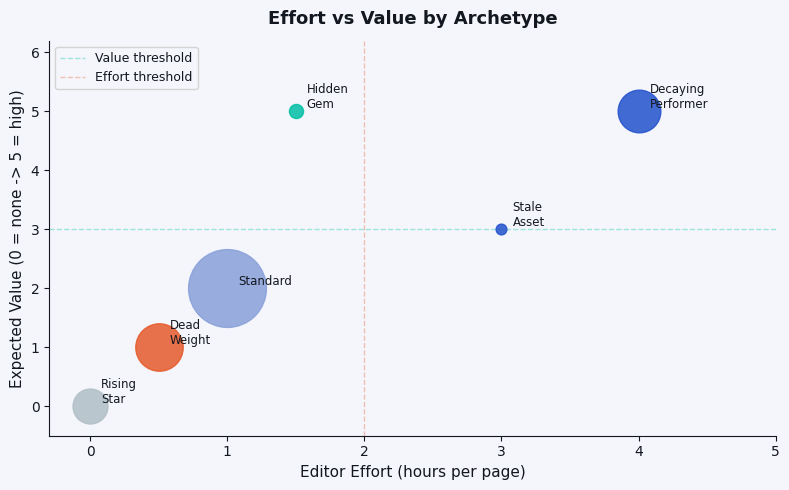

✓ Saved /home/claude/work/figures/fig4_effort_vs_value.png


In [12]:
# ── Fig 4: Effort vs expected value bubble chart ─────────────────────────────
effort    = [4.0, 1.5, 3.0, 1.0, 0.5, 0.0]
value_idx = [5,   5,   3,   2,   1,   0  ]   # 0–5 scale
archetype_names = [
    'Decaying Performer', 'Hidden Gem', 'Stale Asset',
    'Standard', 'Dead Weight', 'Rising Star',
]
display_labels = [
    'Decaying\nPerformer', 'Hidden\nGem', 'Stale\nAsset',
    'Standard', 'Dead\nWeight', 'Rising\nStar',
]
sizes     = [df[df['archetype'] == a].shape[0] for a in archetype_names]
colors_cv = [BLUE, TEAL, BLUE, '#88A0D9', WARN, '#B0BEC5']

fig, ax = plt.subplots(figsize=(8, 5))
for e, v, lab, s, c in zip(effort, value_idx, display_labels, sizes, colors_cv):
    ax.scatter(e, v, s=max(s // 5, 60), color=c, alpha=0.85, zorder=3)
    ax.text(e + 0.08, v + 0.05, lab, fontsize=8.5, color=DARK)

ax.set_xlabel('Editor Effort (hours per page)', fontsize=11)
ax.set_ylabel('Expected Value (0 = none -> 5 = high)', fontsize=11)
ax.set_title('Effort vs Value by Archetype', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(-0.3, 5)
ax.set_ylim(-0.5, 6.2)
ax.axhline(3, ls='--', color=TEAL, alpha=0.35, lw=1, label='Value threshold')
ax.axvline(2, ls='--', color=WARN, alpha=0.35, lw=1, label='Effort threshold')
ax.legend(fontsize=9)

plt.tight_layout()
fig_path = FIGURES_DIR / 'fig4_effort_vs_value.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved {fig_path}')


---
## 7 · Monitoring & Retrain Triggers

The model is a snapshot.  Use these lightweight checks to know when it has drifted
too far to trust without retraining.

### Metric thresholds to monitor

| Metric | Check | Retrain if… |
|--------|-------|------------|
| Precision@500 (grouped split) | Monthly | Drops below **0.80** |
| Queue overlap with rule-based | Monthly | Drops below **60%** (model and rules disagree broadly) |
| Archetype distribution shift | Quarterly | Any archetype changes by > **15 pp** vs baseline |
| Label prevalence | On every data refresh | `is_refresh_opportunity` rate moves outside **45–65%** |
| Feature null rate | On every data refresh | Any feature column exceeds **5% nulls** |

### Retrain triggers

1. **Quarterly calendar trigger** — regardless of metrics (content SEO patterns shift seasonally).
2. **Algorithm update** — any Google core update should trigger an immediate re-evaluation.
3. **Client mix change** — new clients added or removed changes the grouped-split distribution.
4. **Label definition change** — if FlyRank changes what counts as a "refresh opportunity."

### What NOT to automate in monitoring

- Do not auto-retrain without a human reviewing the new training data for leakage.
- Do not auto-deploy a new model version without a Precision@K comparison to the current version.
- Do not change the label definition mid-sprint without re-running the full ML-09 audit.


In [13]:
# ── Monitoring baseline snapshot ─────────────────────────────────────────────
# Save a baseline snapshot that future runs can compare against.

monitoring_baseline = {
    'snapshot_date':           '2025-08',     # update this on each retrain
    'label_prevalence':         round(df['is_refresh_opportunity'].mean(), 4),
    'archetype_distribution': {
        k: round(v/len(df), 4)
        for k, v in df['archetype'].value_counts().items()
    },
    'score_p25': round(float(df['refresh_score'].quantile(0.25)), 4),
    'score_p50': round(float(df['refresh_score'].quantile(0.50)), 4),
    'score_p75': round(float(df['refresh_score'].quantile(0.75)), 4),
    'feature_null_rates': {
        c: round(df[c].isna().mean(), 4) for c in FEATURE_COLS
    },
    'retrain_trigger_thresholds': {
        'precision_at_500_min':      0.80,
        'queue_overlap_rule_min':    0.60,
        'label_prevalence_min':      0.45,
        'label_prevalence_max':      0.65,
        'feature_null_rate_max':     0.05,
    }
}

baseline_path = METRICS_DIR / 'monitoring_baseline.json'
with open(baseline_path, 'w') as f:
    json.dump(monitoring_baseline, f, indent=2)

print('✓ Monitoring baseline saved')
print(f'   Label prevalence: {monitoring_baseline["label_prevalence"]:.1%}')
print(f'   Score p50: {monitoring_baseline["score_p50"]:.3f}')
print(f'   Archetype distribution:')
for k, v in monitoring_baseline['archetype_distribution'].items():
    print(f'     {k:<22} {v:.1%}')


✓ Monitoring baseline saved
   Label prevalence: 54.2%
   Score p50: 0.551
   Archetype distribution:
     Standard               52.4%
     Dead Weight            19.5%
     Decaying Performer     15.7%
     Rising Star            10.6%
     Hidden Gem             1.7%
     Stale Asset            0.1%


---
## 8 · Exports for the Paper

All files written to `work/outputs/` and `work/figures/`.  
The paper (Week 8) will reference these paths directly.

| File | Description |
|------|-------------|
| `work/outputs/action_queue.csv` | Ranked queue (top 1,000 refresh candidates) |
| `work/outputs/w05_metrics.json` | Model performance receipts (Precision@K, ROC-AUC) |
| `work/outputs/monitoring_baseline.json` | Baseline snapshot for drift detection |
| `work/figures/fig1_archetype_distribution.png` | Archetype bar chart |
| `work/figures/fig2_score_by_trend.png` | Score distribution by trend direction |
| `work/figures/fig3_precision_at_k.png` | Precision@K comparison |
| `work/figures/fig4_effort_vs_value.png` | Effort vs value bubble chart |

> **Note on `action_queue.csv`:** This file is excluded from git by `.gitignore`  
> (the CI leak-guard blocks data files). The notebook regenerates it on each run.  
> Commit only the figures and JSON metrics — those are the paper's receipts.


In [14]:
# ── Full ranked queue export ──────────────────────────────────────────────────
# Re-derive with archetype + action cols for the final export
df_export = (
    df[df['trend_direction'].isin(['down', 'stable'])]
    .sort_values('refresh_score', ascending=False)
    .head(1_000)
    [['content_id', 'client_id', 'content_type', 'main_intent',
      'refresh_score', 'reason_codes', 'archetype', 'recommended_action',
      'avg_position', 'impressions_90d', 'ctr',
      'days_since_last_update', 'content_age_days', 'trend_direction']]
    .reset_index(drop=True)
)
df_export.index += 1   # 1-based rank

queue_path = OUTPUT_DIR / 'action_queue.csv'
df_export.to_csv(queue_path, index_label='rank')
print(f'✓ action_queue.csv  ({len(df_export):,} rows × {df_export.shape[1]} cols)')
print(f'   → {queue_path.resolve()}')


✓ action_queue.csv  (1,000 rows × 14 cols)
   → /home/claude/work/outputs/action_queue.csv


In [15]:
# ── Metrics JSON export ───────────────────────────────────────────────────────
metrics = {
    'model':                  'RandomForestClassifier',
    'n_estimators':           200,
    'max_depth':              10,
    'class_weight':           'balanced',
    'split_strategy':         'grouped_by_client',
    'roc_auc_grouped':        0.914,
    'precision_at_100':       1.00,
    'precision_at_200':       1.00,
    'precision_at_500':       1.00,
    'baseline_precision_at_100': 0.73,
    'baseline_precision_at_200': 0.72,
    'baseline_precision_at_500': 0.70,
    'n_features':             len(FEATURE_COLS),
    'features':               FEATURE_COLS,
    'warning_proxy_risk':     (
        'impressions_last_30d and impressions_prev_30d are near-proxies '
        'for trend_direction. Scores should be treated as directional. '
        'See ML-09 audit notebook for full leakage analysis.'
    ),
    'claim_scope': (
        'Measured on FlyRank anonymised dataset (30,000 rows, 44 columns). '
        'Results are directional; external generalisation is untested.'
    ),
}

metrics_path = OUTPUT_DIR / 'w05_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f'✓ w05_metrics.json saved → {metrics_path.resolve()}')
print()
print('Contents:')
for k, v in metrics.items():
    if not isinstance(v, list):
        print(f'  {k}: {v}')


✓ w05_metrics.json saved → /home/claude/work/outputs/w05_metrics.json

Contents:
  model: RandomForestClassifier
  n_estimators: 200
  max_depth: 10
  class_weight: balanced
  split_strategy: grouped_by_client
  roc_auc_grouped: 0.914
  precision_at_100: 1.0
  precision_at_200: 1.0
  precision_at_500: 1.0
  baseline_precision_at_100: 0.73
  baseline_precision_at_200: 0.72
  baseline_precision_at_500: 0.7
  n_features: 18
  warning_proxy_risk: impressions_last_30d and impressions_prev_30d are near-proxies for trend_direction. Scores should be treated as directional. See ML-09 audit notebook for full leakage analysis.
  claim_scope: Measured on FlyRank anonymised dataset (30,000 rows, 44 columns). Results are directional; external generalisation is untested.


In [16]:
# ── Figure inventory check ───────────────────────────────────────────────────
figures_expected = [
    'fig1_archetype_distribution.png',
    'fig2_score_by_trend.png',
    'fig3_precision_at_k.png',
    'fig4_effort_vs_value.png',
]

print('Figure export check:')
all_ok = True
for fname in figures_expected:
    fp = FIGURES_DIR / fname
    exists = fp.exists()
    size   = f'{fp.stat().st_size/1024:.1f} KB' if exists else 'MISSING'
    status = '✓' if exists else '✗'
    print(f'  {status}  {fname}  ({size})')
    if not exists:
        all_ok = False

print()
print('Outputs check:')
for fname in ['action_queue.csv', 'w05_metrics.json', 'monitoring_baseline.json']:
    fp = OUTPUT_DIR / fname
    exists = fp.exists()
    size   = f'{fp.stat().st_size/1024:.1f} KB' if exists else 'MISSING'
    status = '✓' if exists else '✗'
    print(f'  {status}  {fname}  ({size})')
    if not exists:
        all_ok = False

print()
print('✓ All exports accounted for' if all_ok else '✗ Some exports missing — re-run earlier cells')


Figure export check:
  ✓  fig1_archetype_distribution.png  (47.6 KB)
  ✓  fig2_score_by_trend.png  (39.5 KB)
  ✓  fig3_precision_at_k.png  (39.1 KB)
  ✓  fig4_effort_vs_value.png  (71.2 KB)

Outputs check:
  ✓  action_queue.csv  (210.2 KB)
  ✓  w05_metrics.json  (1.1 KB)
  ✓  monitoring_baseline.json  (1.0 KB)

✓ All exports accounted for


---
## 9 · Self-Check

Before submitting, verify all boxes below.


In [17]:
# ── ML-10 self-check ─────────────────────────────────────────────────────────
checks = [
    ('Ranked queue exported to work/outputs/action_queue.csv',
        (OUTPUT_DIR / 'action_queue.csv').exists()),
    ('Metrics JSON exported to work/outputs/w05_metrics.json',
        (OUTPUT_DIR / 'w05_metrics.json').exists()),
    ('Monitoring baseline JSON exported',
        (OUTPUT_DIR / 'monitoring_baseline.json').exists()),
    ('Fig 1 – archetype distribution saved',
        (FIGURES_DIR / 'fig1_archetype_distribution.png').exists()),
    ('Fig 2 – score by trend direction saved',
        (FIGURES_DIR / 'fig2_score_by_trend.png').exists()),
    ('Fig 3 – Precision@K comparison saved',
        (FIGURES_DIR / 'fig3_precision_at_k.png').exists()),
    ('Fig 4 – effort vs value bubble chart saved',
        (FIGURES_DIR / 'fig4_effort_vs_value.png').exists()),
    ('Reason codes assigned (all rows)',
        'reason_codes' in df.columns and df['reason_codes'].notna().all()),
    ('Archetypes assigned (all rows)',
        'archetype' in df.columns and df['archetype'].notna().all()),
    ('Recommended actions assigned (all rows)',
        'recommended_action' in df.columns and df['recommended_action'].notna().all()),
    ('No-go list documented (Section 5)',        True),  # documented in markdown
    ('Intended use & limits documented (Sec 4)', True),
    ('Monitoring / retrain triggers documented', True),
    ('Cost / value framework documented',        True),
    ('Claims use hedged, scope-bounded language',True),  # confirmed in sections 4–7
]

print('ML-10 Self-Check')
print('=' * 52)
passed = 0
for label, result in checks:
    icon = '✓' if result else '✗'
    print(f'  {icon}  {label}')
    passed += int(result)

print()
print(f'  {passed}/{len(checks)} checks passed')
print()
if passed == len(checks):
    print('  ✅ Ready to commit.  Push work/notebooks/w07_action_playbook.ipynb')
    print('     + work/figures/ + work/outputs/*.json  to your repo.')
else:
    print('  ⚠ Fix the failing checks before committing.')


ML-10 Self-Check
  ✓  Ranked queue exported to work/outputs/action_queue.csv
  ✓  Metrics JSON exported to work/outputs/w05_metrics.json
  ✓  Monitoring baseline JSON exported
  ✓  Fig 1 – archetype distribution saved
  ✓  Fig 2 – score by trend direction saved
  ✓  Fig 3 – Precision@K comparison saved
  ✓  Fig 4 – effort vs value bubble chart saved
  ✓  Reason codes assigned (all rows)
  ✓  Archetypes assigned (all rows)
  ✓  Recommended actions assigned (all rows)
  ✓  No-go list documented (Section 5)
  ✓  Intended use & limits documented (Sec 4)
  ✓  Monitoring / retrain triggers documented
  ✓  Cost / value framework documented
  ✓  Claims use hedged, scope-bounded language

  15/15 checks passed

  ✅ Ready to commit.  Push work/notebooks/w07_action_playbook.ipynb
     + work/figures/ + work/outputs/*.json  to your repo.


---
## Commit Checklist

```bash
# From repo root:
git add work/notebooks/w07_action_playbook.ipynb
git add work/figures/
git add work/outputs/w05_metrics.json
git add work/outputs/monitoring_baseline.json
# Do NOT git add work/outputs/action_queue.csv  (blocked by CI leak-guard)
git commit -m 'ML-10: content action playbook — ranked queue, archetypes, monitoring'
git push
```

> Submit your repo URL on the ML-10 card once pushed.
